# Gold nanoparticle reconstruction in quantem 

Notebook from Georgios Varnavides and Stephanie Ribet

Data collected by Stephanie Ribet, TEAM I, Jan 2025

In [1]:
import numpy as np
import quantem as em
import matplotlib.pyplot as plt

em.core.config.set_device(1)
print(em.__version__)

0.1.8


# load data

In [2]:
# Data can be downloaded from https://doi.org/10.5281/zenodo.18449974
dc = em.io.load("data/gold_arina_calibrated.zip")
dc

Dataset(shape=(154, 154, 192, 192), dtype=uint16, name='4D-STEM dataset')
  sampling: [1.328125  1.328125  0.4547657 0.4547657]
  units: ['A', 'A', 'mrad', 'mrad']
  signal units: 'arb. units'

In [3]:
# calibrations
PROBE_SEMIANGLE = 21.9
ENERGY = 300e3

# iterative ptycho

In [4]:
pdset = em.diffractive_imaging.PtychographyDatasetRaster.from_dataset4dstem(dc)

pdset.preprocess(
    com_fit_function="constant",
    plot_rotation=False,
    plot_com=False,
    probe_energy=ENERGY,
    force_com_rotation=-169,
    force_com_transpose = False,
);

Forcing best fit rotation to -169 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/23716 [00:00<?, ?probe position/s]

In [5]:
ptycho_pix = em.diffractive_imaging.PtychoLite.from_dataset(
    dset=pdset,
    num_slices=8,
    obj_type="potential",
    num_probes=3,
    energy=ENERGY,
    semiangle_cutoff=PROBE_SEMIANGLE,
    obj_padding_px=(64,64),
    device="cpu",
    polar_parameters = {
        'C10': -330.33740092814674,
        'C12': 67.33092828772897, 
        'phi12': 0.00145768024663398,
    },
    middle_focus=True,
    slice_thicknesses=20,
)

In [ ]:
constraints = {
    "object":{
        "fix_potential_baseline": True,
        "fix_potential_baseline_factor": 0.5,
        "tv_weight_z": 1000,
    }
}

ptycho_pix.reconstruct(
    num_iters=50, 
    batch_size=384,
    constraints=constraints,
    reset = True,
    device=em.core.config.get_device()
)

  0%|          | 0/50 [00:00<?, ?it/s]

# dip

Iter 150/150, Loss: 1.931e-03, : 100%|████████| 150/150 [00:18<00:00,  8.21it/s]


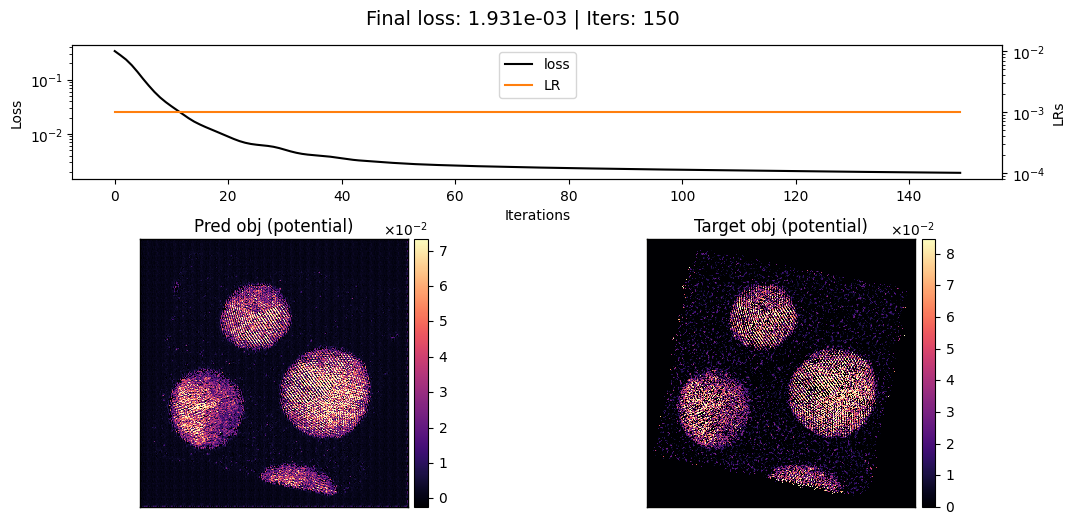

Iter 150/150, Loss: 7.705e-03, : 100%|████████| 150/150 [00:09<00:00, 15.46it/s]


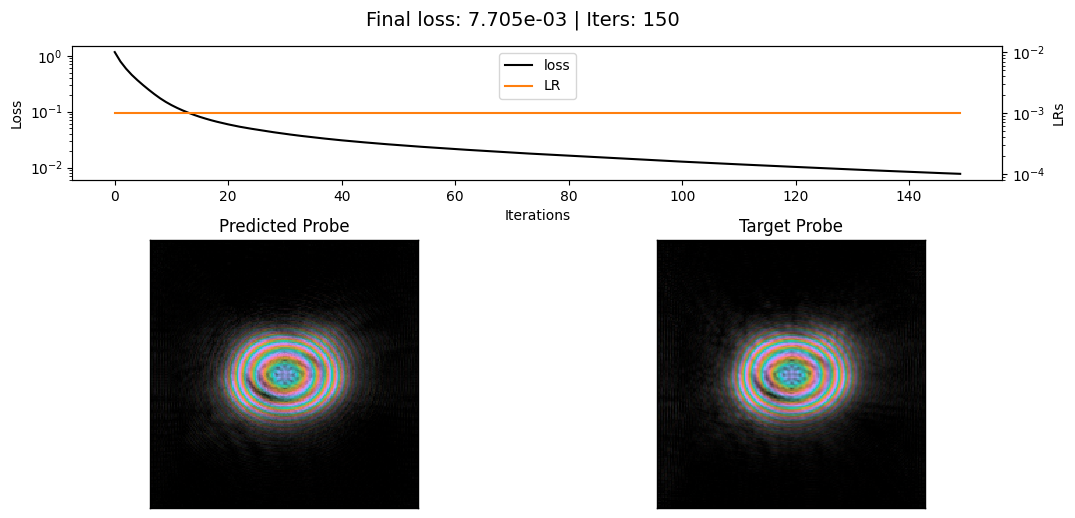

In [24]:
ptycho_dip = em.diffractive_imaging.PtychoLiteDIP.from_ptycholite(
    ptycholite=ptycho_pix,
    pretrain_iters=150,
    device=em.core.config.get_device(),
    verbose=False,
    # pretrain_object=False,
)

Iter 5/5, Loss: 1.092e+03: 100%|██████████████████| 5/5 [03:08<00:00, 37.73s/it]


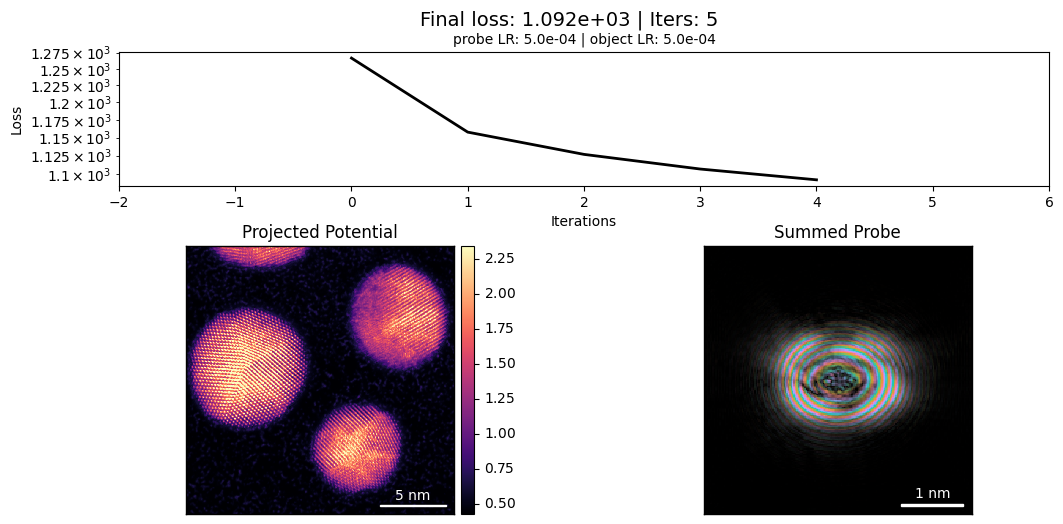

In [26]:
constraints = {
    "object":{
        "fix_potential_baseline": True,
        "fix_potential_baseline_factor": 0.5,
        "q_lowpass": 1.3,
        "identical_slices":True,
    }
}

ptycho_dip.reconstruct(
    num_iters=10, 
    reset=True, 
    scheduler_type='plateau', 
    batch_size=384,
    constraints=constraints
)

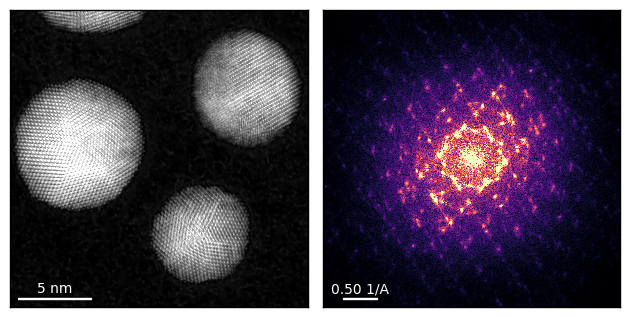

In [35]:
def fft(ar): 
    n0 = ar.shape
    w0 = np.hanning(n0[1]) * np.hanning(n0[0])[:, None]
    ar_fft = np.abs(np.fft.fftshift(np.fft.fft2(w0 * ar.copy())))
    return ar_fft

fig, ax = plt.subplots(1,2)

em.visualization.show_2d(
      ptycho_dip.obj_cropped.sum(0),
      figax = (fig, ax[0]), 
      scalebar = {
        'sampling':ptycho_dip.sampling[0]/10,
        'units':'nm',
        'length':5,
        'loc':3,   
    }
)


em.visualization.show_2d(
      fft(ptycho_dip.obj_cropped.sum(0)),
      figax = (fig, ax[1]), 
      scalebar = {
        'sampling':np.fft.fftfreq(ptycho_dip.obj_cropped.shape[1],ptycho_dip.sampling[0])[1],
        'units':'1/A',
        'length':0.5,
        'loc':3,   
     },
     norm = norm,
      cmap = "magma"
)
